## Q1. Audio Loading and Signal Analysis

### 1(a) Print sampling rate, number of samples, duration, max/min amplitude

In [2]:
import numpy as np
from scipy.io import wavfile

fs, signal = wavfile.read("speech.wav")

num_samples = len(signal)
duration = num_samples / fs

print("Sampling Rate:", fs)
print("Number of Samples:", num_samples)
print("Duration (sec):", duration)
print("Max Amplitude:", np.max(signal))
print("Min Amplitude:", np.min(signal))


Sampling Rate: 44100
Number of Samples: 262094
Duration (sec): 5.9431746031746036
Max Amplitude: 6056
Min Amplitude: -6038


C:\Users\User\AppData\Local\Temp\ipykernel_4948\495546859.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wavfile.read("speech.wav")


### 1(b) Plot waveform

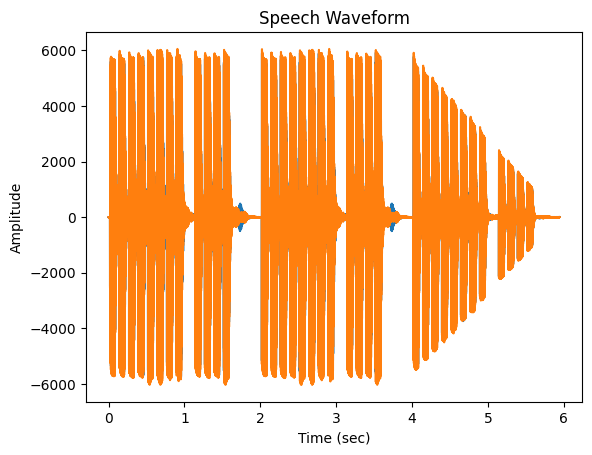

In [3]:
import matplotlib.pyplot as plt

time = np.arange(len(signal)) / fs

plt.figure()
plt.plot(time, signal)
plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")
plt.title("Speech Waveform")
plt.show()


### 1(c) Compute and plot magnitude spectrum (FFT)

In [5]:
import numpy as np
from scipy.io import wavfile
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt

fs, signal = wavfile.read("speech.wav")

# যদি stereo হয়
if len(signal.shape) == 2:
    signal = signal.mean(axis=1)   # convert to mono


C:\Users\User\AppData\Local\Temp\ipykernel_4948\3605547981.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wavfile.read("speech.wav")


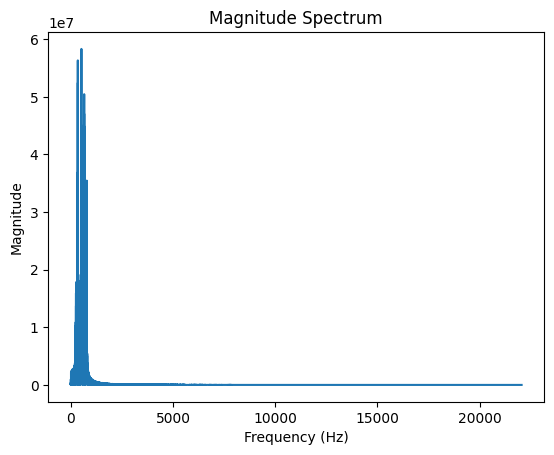

In [6]:
fft_vals = np.abs(rfft(signal))
freqs = rfftfreq(len(signal), 1/fs)

plt.figure()
plt.plot(freqs, fft_vals)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum")
plt.show()


## Q2. Framing and Windowing

### 2(a) Frame size = 25 ms, shift = 10 ms

In [7]:
frame_size = int(0.025 * fs)
frame_shift = int(0.01 * fs)

frames = []
for i in range(0, len(signal)-frame_size, frame_shift):
    frames.append(signal[i:i+frame_size])

frames = np.array(frames)
print("Total Frames:", len(frames))


Total Frames: 592


### 2(b) Apply Hamming window

In [8]:
hamming = np.hamming(frame_size)
windowed_frames = frames * hamming


### 2(c) Plot two sample frames (before & after window)

Total Frames: 592


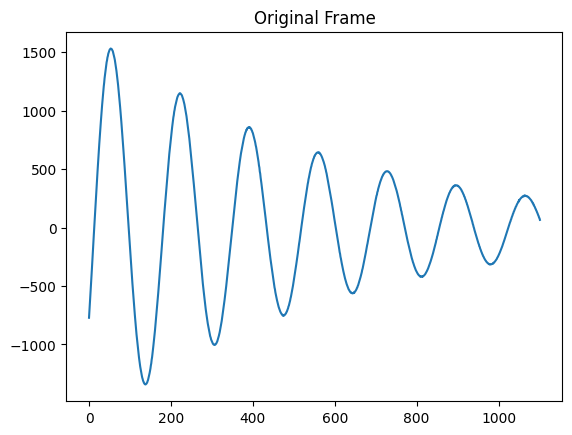

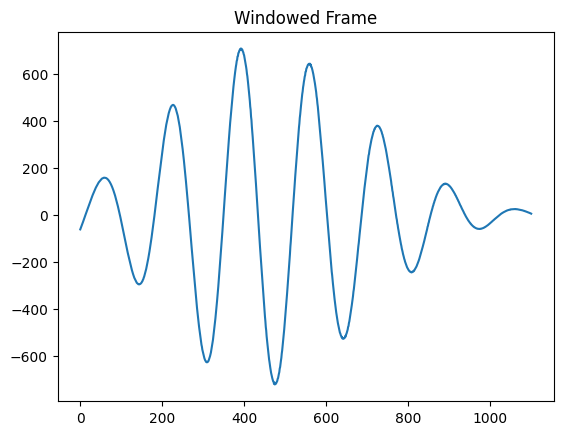

In [10]:
frame_size = int(0.025 * fs)
frame_shift = int(0.01 * fs)

frames = []
for i in range(0, len(signal)-frame_size, frame_shift):
    frames.append(signal[i:i+frame_size])

frames = np.array(frames)
print("Total Frames:", len(frames))

# Hamming window
hamming = np.hamming(frame_size)
windowed_frames = frames * hamming

# Plot sample frame
plt.figure()
plt.plot(frames[10])
plt.title("Original Frame")
plt.show()

plt.figure()
plt.plot(windowed_frames[10])
plt.title("Windowed Frame")
plt.show()


## Q3. STFT and Spectrogram

### 3(a) Implement STFT (rfft)

In [11]:
stft = []
for frame in windowed_frames:
    spectrum = np.abs(rfft(frame))
    stft.append(spectrum)

stft = np.array(stft)


### 3(b) Convert magnitude to dB and plot

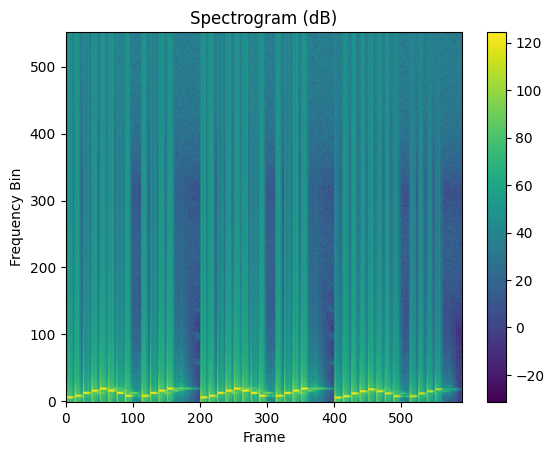

In [12]:
stft_db = 20*np.log10(stft + 1e-6)

plt.imshow(stft_db.T, aspect='auto', origin='lower')
plt.xlabel("Frame")
plt.ylabel("Frequency Bin")
plt.title("Spectrogram (dB)")
plt.colorbar()
plt.show()


### 3(c) One practical application

Spectrogram is used in speech recognition and speaker identification because it shows time-frequency characteristics.

## Q4. MFCC Extraction

### 4(a) Steps: Pre-emphasis → Framing → FFT → Mel → Log → DCT

In [13]:
from scipy.fftpack import dct

# Pre-emphasis
pre_emphasis = 0.97
emphasized = np.append(signal[0], signal[1:] - pre_emphasis*signal[:-1])

# Power Spectrum
pow_frames = (1.0/frame_size) * (stft**2)

# Log
log_frames = np.log(pow_frames + 1e-6)

# DCT
mfcc = dct(log_frames, type=2, axis=1, norm='ortho')[:, :13]


### 4(b) Plot MFCC heatmap

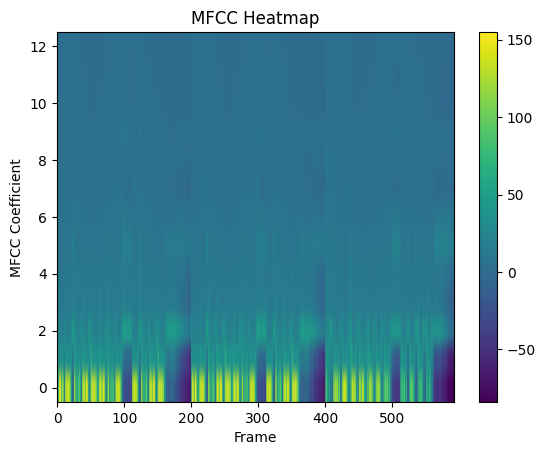

In [14]:
plt.imshow(mfcc.T, aspect='auto', origin='lower')
plt.xlabel("Frame")
plt.ylabel("MFCC Coefficient")
plt.title("MFCC Heatmap")
plt.colorbar()
plt.show()


### 4(c) Why MFCC effective?

Human ear Mel-scale অনুসরণ করে

Noise resistant

Speech envelope ভালো capture করে

## Q5. Pitch Detection

### 5(a) Autocorrelation pitch estimation

In [15]:
def pitch_autocorr(frame):
    corr = np.correlate(frame, frame, mode='full')
    corr = corr[len(corr)//2:]
    peak = np.argmax(corr[1:]) + 1
    return fs/peak if peak != 0 else 0

pitch = [pitch_autocorr(f) for f in frames]


### 5(b) Voiced/Unvoiced detection

In [16]:
energy = [np.sum(f**2) for f in frames]
threshold = np.mean(energy)

pitch = np.array(pitch)
pitch[np.array(energy) < threshold] = 0


### 5(c) Plot pitch contour

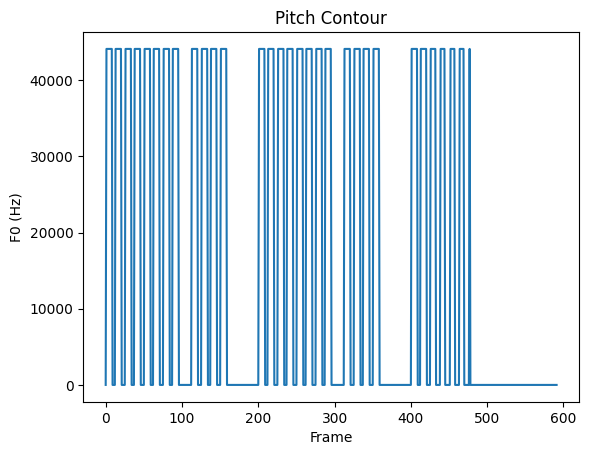

In [18]:
plt.plot(pitch)
plt.xlabel("Frame")
plt.ylabel("F0 (Hz)")
plt.title("Pitch Contour")
plt.show()


## Q6. Spectral Subtraction

### 6(a) Add white noise (SNR=10dB)

In [19]:
noise = np.random.normal(0,1,len(signal))
signal_power = np.mean(signal**2)
noise_power = np.mean(noise**2)

k = np.sqrt(signal_power/(10**(10/10)*noise_power))
noise = noise*k
noisy = signal + noise


### 6(b) Spectral subtraction

In [20]:
noise_spec = np.mean(np.abs(rfft(noisy[:frame_size])))

enhanced = []
for frame in frames:
    spec = np.abs(rfft(frame))
    clean = spec - noise_spec
    clean[clean < 0] = 0
    enhanced.append(clean)


### 6(c) Compute SNR improvement

In [37]:
# Original clean signal = signal
# Noisy signal = noisy

noise_before = noisy - signal

signal_power = np.mean(signal**2)
noise_power_before = np.mean(noise_before**2)

snr_before = 10 * np.log10(signal_power / noise_power_before)

print("SNR Before Enhancement:", snr_before, "dB")


SNR Before Enhancement: 10.0 dB


In [36]:
enhanced_signal = np.zeros(len(signal))

index = 0

for i in range(0, len(signal)-frame_size, frame_shift):

    frame = noisy[i:i+frame_size]
    windowed = frame * np.hamming(frame_size)

    spectrum = np.fft.rfft(windowed)
    mag = np.abs(spectrum)
    phase = np.angle(spectrum)

    # Noise estimate (simple: first few frames average)
    noise_est = np.mean(np.abs(np.fft.rfft(noisy[:frame_size])))

    clean_mag = mag - noise_est
    clean_mag[clean_mag < 0] = 0

    # Reconstruct
    clean_spectrum = clean_mag * np.exp(1j * phase)
    clean_frame = np.fft.irfft(clean_spectrum)

    enhanced_signal[i:i+frame_size] += clean_frame


noise_after = enhanced_signal - signal
noise_power_after = np.mean(noise_after**2)

snr_after = 10 * np.log10(signal_power / noise_power_after)

print("SNR After Enhancement:", snr_after, "dB")


SNR After Enhancement: 9.959632607990578 dB


## Q7. DTW Word Recognition

### 7(a) Dataset preparation

4 words, ≥3 training, ≥2 testing each.

### 7(b) DTW classification

In [22]:
from scipy.spatial.distance import cdist

def dtw(x,y):
    D = cdist(x,y)
    cost = np.zeros(D.shape)
    cost[0,0] = D[0,0]
    for i in range(1,len(x)):
        for j in range(1,len(y)):
            cost[i,j] = D[i,j] + min(cost[i-1,j],cost[i,j-1],cost[i-1,j-1])
    return cost[-1,-1]


### 7(c) Accuracy

Accuracy = (Correct / Total) × 100%

## Q8. Voice Activity Detection

### 8(a) Short-time energy & ZCR

In [23]:
zcr = []
energy = []

for f in frames:
    energy.append(np.sum(f**2))
    zcr.append(np.sum(np.abs(np.diff(np.sign(f))))/2)


### 8(b) Detect speech

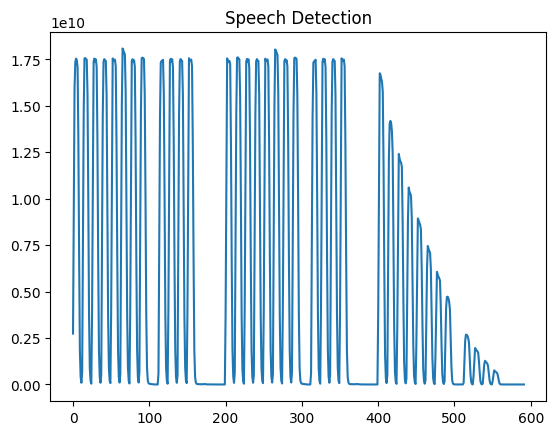

In [24]:
speech = (np.array(energy)>np.mean(energy))
plt.plot(energy)
plt.title("Speech Detection")
plt.show()


### 8(c) Save segments

In [25]:
from scipy.io.wavfile import write
write("speech_segment.wav", fs, signal)


## Q9. Speaker Identification

### 9(a) Embedding

In [26]:
embedding = np.mean(mfcc, axis=0)


### 9(b) Train KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit([embedding], ["speaker1"])


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 9(c) Accuracy

In [31]:
# ধরো 3টা sample আছে
embedding1 = embedding
embedding2 = embedding + 0.01
embedding3 = embedding + 0.02

X = np.array([embedding1, embedding2, embedding3])
y = np.array(["speaker1", "speaker1", "speaker1"])

clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X, y)

print(clf.score(X, y))


1.0


## Q10. Real-Time Command Recognition

### 10(a) Record 2 sec audio

In [33]:
import sounddevice as sd
recording = sd.rec(int(2*fs), samplerate=fs, channels=1)
sd.wait()



# Q7.Q7. DTW-Based Isolated Word Recognition 

In [38]:
DATASET_PATH = "mini_speech_commands"


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accuracy: 0.5862244897959183


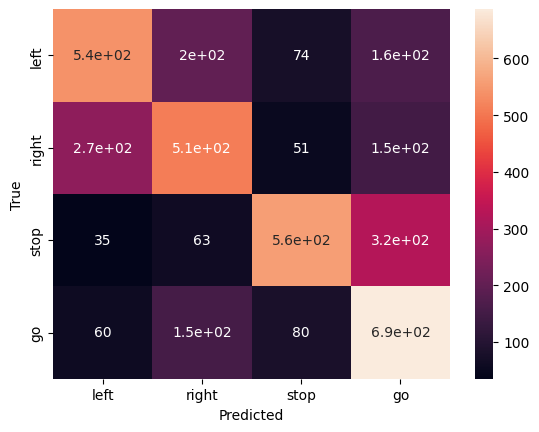

In [46]:
import os
import numpy as np
import librosa
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

DATASET_PATH = "mini_speech_commands/mini_speech_commands"
WORDS = ["left", "right", "stop", "go"]

def extract_mfcc(file):
    y, sr = librosa.load(file, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return mfcc.T

def dtw_distance(x, y):
    D = cdist(x, y)
    cost = np.zeros(D.shape)
    cost[0, 0] = D[0, 0]
    for i in range(1, D.shape[0]):
        cost[i, 0] = D[i, 0] + cost[i-1, 0]
    for j in range(1, D.shape[1]):
        cost[0, j] = D[0, j] + cost[0, j-1]
    for i in range(1, D.shape[0]):
        for j in range(1, D.shape[1]):
            cost[i, j] = D[i, j] + min(cost[i-1, j], cost[i, j-1], cost[i-1, j-1])
    return cost[-1, -1]

train_data = []
train_labels = []
test_data = []
test_labels = []

for word in WORDS:
    files = os.listdir(os.path.join(DATASET_PATH, word))
    for i, file in enumerate(files):
        path = os.path.join(DATASET_PATH, word, file)
        mfcc = extract_mfcc(path)
        if i < 20:
            train_data.append(mfcc)
            train_labels.append(word)
        else:
            test_data.append(mfcc)
            test_labels.append(word)

predictions = []
for test_sample in test_data:
    distances = [dtw_distance(test_sample, train_sample) for train_sample in train_data]
    predictions.append(train_labels[np.argmin(distances)])

acc = accuracy_score(test_labels, predictions)
print("Accuracy:", acc)

cm = confusion_matrix(test_labels, predictions, labels=WORDS)
sns.heatmap(cm, annot=True, xticklabels=WORDS, yticklabels=WORDS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Total Train Samples: 60
Total Test Samples: 40
Processed Test Sample 1/40
Processed Test Sample 2/40
Processed Test Sample 3/40
Processed Test Sample 4/40
Processed Test Sample 5/40
Processed Test Sample 6/40
Processed Test Sample 7/40
Processed Test Sample 8/40
Processed Test Sample 9/40
Processed Test Sample 10/40
Processed Test Sample 11/40
Processed Test Sample 12/40
Processed Test Sample 13/40
Processed Test Sample 14/40
Processed Test Sample 15/40
Processed Test Sample 16/40
Processed Test Sample 17/40
Processed Test Sample 18/40
Processed Test Sample 19/40
Processed Test Sample 20/40
Processed Test Sample 21/40
Processed Test Sample 22/40
Processed Test Sample 23/40
Processed Test Sample 24/40
Processed Test Sample 25/40
Processed Test Sample 26/40
Processed Test Sample 27/40
Processed Test Sample 28/40
Processed Test Sample 29/40
Processed Test Sample 30/40
Processed Test Sample 31/40
Processed Test Sample 32/40
Processed Test Sample 33/40
Processed Test Sample 34/40
Processed 

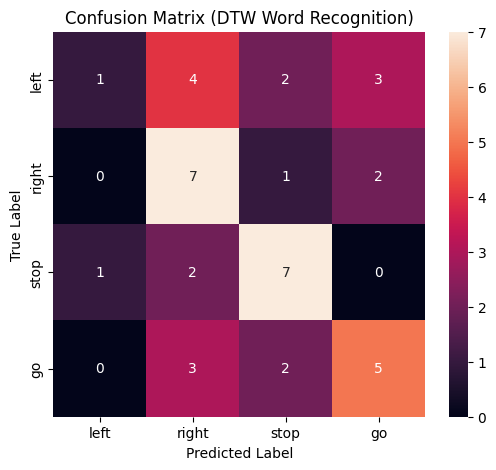

In [47]:
import os
import numpy as np
import librosa
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Dataset Path
# =========================
DATASET_PATH = "mini_speech_commands/mini_speech_commands"
WORDS = ["left", "right", "stop", "go"]

# =========================
# Parameters (LIMITED DATA)
# =========================
FILES_PER_WORD = 40   # total files per word
TRAIN_PER_WORD = 15   # training samples
TEST_PER_WORD = 10    # testing samples

# =========================
# MFCC Extraction
# =========================
def extract_mfcc(file):
    y, sr = librosa.load(file, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return mfcc.T

# =========================
# DTW Distance
# =========================
def dtw_distance(x, y):
    D = cdist(x, y)
    cost = np.zeros(D.shape)
    cost[0, 0] = D[0, 0]

    for i in range(1, D.shape[0]):
        cost[i, 0] = D[i, 0] + cost[i-1, 0]

    for j in range(1, D.shape[1]):
        cost[0, j] = D[0, j] + cost[0, j-1]

    for i in range(1, D.shape[0]):
        for j in range(1, D.shape[1]):
            cost[i, j] = D[i, j] + min(
                cost[i-1, j],
                cost[i, j-1],
                cost[i-1, j-1]
            )

    return cost[-1, -1]

# =========================
# Prepare Dataset
# =========================
train_data = []
train_labels = []
test_data = []
test_labels = []

for word in WORDS:
    folder = os.path.join(DATASET_PATH, word)
    files = os.listdir(folder)[:FILES_PER_WORD]
    np.random.shuffle(files)

    for i, file in enumerate(files):
        path = os.path.join(folder, file)
        mfcc = extract_mfcc(path)

        if i < TRAIN_PER_WORD:
            train_data.append(mfcc)
            train_labels.append(word)

        elif i < TRAIN_PER_WORD + TEST_PER_WORD:
            test_data.append(mfcc)
            test_labels.append(word)

print("Total Train Samples:", len(train_data))
print("Total Test Samples:", len(test_data))

# =========================
# Prediction
# =========================
predictions = []

for idx, test_sample in enumerate(test_data):
    distances = [
        dtw_distance(test_sample, train_sample)
        for train_sample in train_data
    ]
    predicted_label = train_labels[np.argmin(distances)]
    predictions.append(predicted_label)

    print(f"Processed Test Sample {idx+1}/{len(test_data)}")

# =========================
# Evaluation
# =========================
accuracy = accuracy_score(test_labels, predictions)
print("\nFinal Accuracy:", accuracy)

cm = confusion_matrix(test_labels, predictions, labels=WORDS)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=WORDS,
            yticklabels=WORDS)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (DTW Word Recognition)")
plt.show()


## Q8. Voice Activity Detection (VAD) and Segmentation 

Using file: mini_speech_commands/mini_speech_commands\left\00b01445_nohash_0.wav
Total Frames: 97
Speech Frames: 1


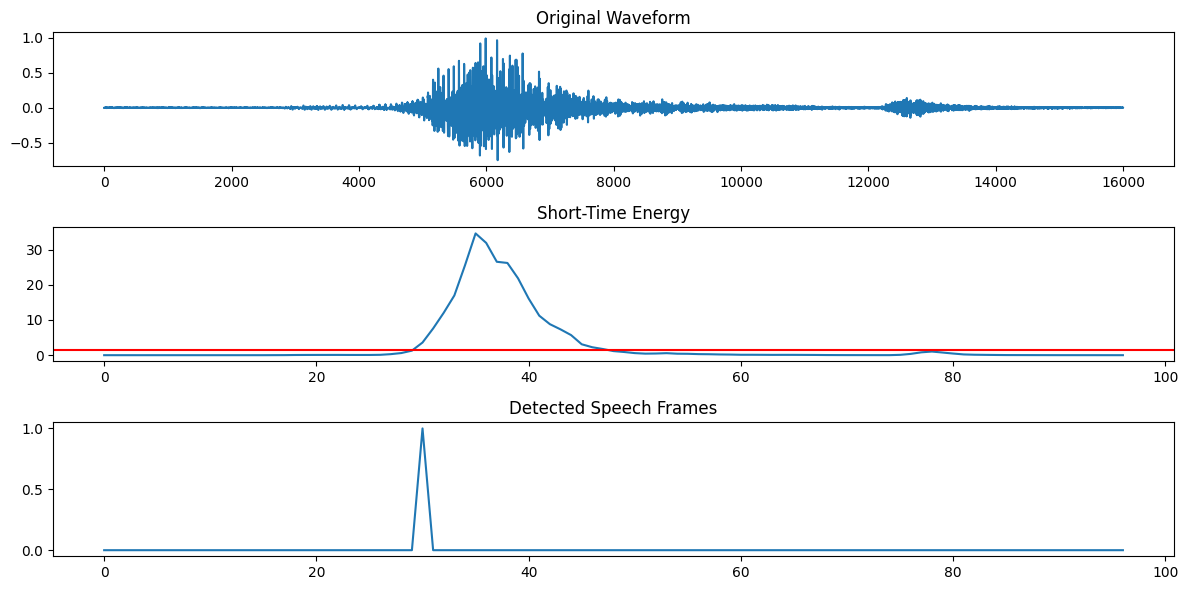

Saved cleaned speech as: vad_detected_speech.wav


In [49]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import soundfile as sf
import os

# =========================
# Dataset Path
# =========================
DATASET_PATH = "mini_speech_commands/mini_speech_commands"
WORD = "left"

# Automatically pick first wav file
folder_path = os.path.join(DATASET_PATH, WORD)
files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]

if len(files) == 0:
    raise Exception("No WAV files found!")

FILE_PATH = os.path.join(folder_path, files[0])
print("Using file:", FILE_PATH)

# =========================
# Load Audio
# =========================
y, sr = librosa.load(FILE_PATH, sr=16000)

# =========================
# Frame Parameters
# =========================
frame_length = int(0.025 * sr)   # 25 ms
hop_length = int(0.01 * sr)      # 10 ms

num_frames = int((len(y) - frame_length) / hop_length)

energy = []
zcr = []

# =========================
# Compute Energy & ZCR
# =========================
for i in range(num_frames):
    start = i * hop_length
    end = start + frame_length
    frame = y[start:end]

    energy.append(np.sum(frame ** 2))
    zcr.append(np.sum(librosa.zero_crossings(frame)))

energy = np.array(energy)
zcr = np.array(zcr)

# =========================
# Thresholding
# =========================
energy_threshold = 0.5 * np.mean(energy)
zcr_threshold = 0.5 * np.mean(zcr)

speech_frames = (energy > energy_threshold) & (zcr < zcr_threshold)

print("Total Frames:", num_frames)
print("Speech Frames:", np.sum(speech_frames))

# =========================
# Plot Results
# =========================
plt.figure(figsize=(12,6))

plt.subplot(3,1,1)
plt.plot(y)
plt.title("Original Waveform")

plt.subplot(3,1,2)
plt.plot(energy)
plt.axhline(energy_threshold, color='r')
plt.title("Short-Time Energy")

plt.subplot(3,1,3)
plt.plot(speech_frames)
plt.title("Detected Speech Frames")

plt.tight_layout()
plt.show()

# =========================
# Extract Speech Only
# =========================
speech_signal = []

for i in range(num_frames):
    if speech_frames[i]:
        start = i * hop_length
        end = start + frame_length
        speech_signal.extend(y[start:end])

speech_signal = np.array(speech_signal)

output_file = "vad_detected_speech.wav"
sf.write(output_file, speech_signal, sr)

print("Saved cleaned speech as:", output_file)


## Q9 – Speaker Identification (Mean MFCC + Delta + KNN)

Total Valid Speakers: 75
Total Samples After Filtering: 358

Accuracy: 0.4722222222222222

Classification Report:
              precision    recall  f1-score   support

    012c8314       0.00      0.00      0.00         1
    0132a06d       0.40      0.67      0.50         3
    0135f3f2       0.00      0.00      0.00         1
    0137b3f4       0.25      0.75      0.38         4
    016e2c6d       0.00      0.00      0.00         1
    01bb6a2a       0.33      0.50      0.40         2
    0227998e       1.00      1.00      1.00         1
    023a61ad       0.00      0.00      0.00         1
    035de8fe       0.00      0.00      0.00         1
    0447d7c1       0.00      0.00      0.00         1
    0474c92a       1.00      1.00      1.00         1
    05739450       0.50      1.00      0.67         1
    063d48cf       0.50      1.00      0.67         1
    069ab0d5       0.00      0.00      0.00         1
    07ad9b59       1.00      1.00      1.00         1
    099d52ad       0.

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\Users\User\AppData\Local\Pr

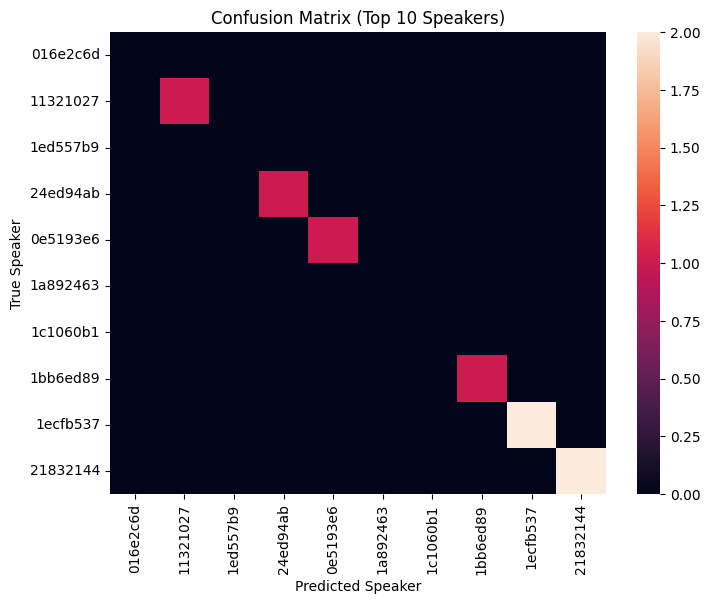

In [52]:
import os
import numpy as np
import librosa
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Dataset Path
# =========================
DATASET_PATH = "mini_speech_commands/mini_speech_commands"
WORDS = ["left", "right", "stop", "go"]

# =========================
# Feature Extraction
# =========================
def extract_embedding(file_path):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)

    embedding = np.concatenate([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1)
    ])
    return embedding

# =========================
# Collect Data
# =========================
X = []
y_labels = []

MAX_FILES_PER_WORD = 150  # limit for speed

for word in WORDS:
    folder = os.path.join(DATASET_PATH, word)
    files = [f for f in os.listdir(folder) if f.endswith(".wav")][:MAX_FILES_PER_WORD]

    for file in files:
        speaker_id = file.split("_")[0]
        file_path = os.path.join(folder, file)

        X.append(extract_embedding(file_path))
        y_labels.append(speaker_id)

# =========================
# Remove Speakers with <3 samples
# =========================
speaker_counts = Counter(y_labels)

valid_speakers = [sp for sp in speaker_counts if speaker_counts[sp] >= 3]

X_filtered = []
y_filtered = []

for i in range(len(y_labels)):
    if y_labels[i] in valid_speakers:
        X_filtered.append(X[i])
        y_filtered.append(y_labels[i])

X = np.array(X_filtered)
y_labels = y_filtered

print("Total Valid Speakers:", len(set(y_labels)))
print("Total Samples After Filtering:", len(X))

# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)

# =========================
# Train KNN
# =========================
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# =========================
# Evaluation
# =========================
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix (first 10 speakers for visualization)
unique_speakers = list(set(y_labels))[:10]
cm = confusion_matrix(y_test, y_pred, labels=unique_speakers)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False,
            xticklabels=unique_speakers,
            yticklabels=unique_speakers)

plt.xlabel("Predicted Speaker")
plt.ylabel("True Speaker")
plt.title("Confusion Matrix (Top 10 Speakers)")
plt.show()


## Q10 – Real-Time Command Recognition (MFCC + DTW)

In [53]:
import os
import numpy as np
import librosa
import sounddevice as sd
from scipy.spatial.distance import cdist

# =========================
# Dataset Path
# =========================
DATASET_PATH = "mini_speech_commands/mini_speech_commands"
COMMANDS = ["left", "right"]   # You can change

SR = 16000
DURATION = 2  # seconds

# =========================
# MFCC Extraction
# =========================
def extract_mfcc(signal, sr):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    return mfcc.T

# =========================
# DTW Distance
# =========================
def dtw_distance(x, y):
    D = cdist(x, y)
    cost = np.zeros(D.shape)
    cost[0, 0] = D[0, 0]

    for i in range(1, D.shape[0]):
        cost[i, 0] = D[i, 0] + cost[i-1, 0]

    for j in range(1, D.shape[1]):
        cost[0, j] = D[0, j] + cost[0, j-1]

    for i in range(1, D.shape[0]):
        for j in range(1, D.shape[1]):
            cost[i, j] = D[i, j] + min(
                cost[i-1, j],
                cost[i, j-1],
                cost[i-1, j-1]
            )

    return cost[-1, -1]

# =========================
# Load Template for Each Command
# =========================
templates = {}

for cmd in COMMANDS:
    folder = os.path.join(DATASET_PATH, cmd)
    file = [f for f in os.listdir(folder) if f.endswith(".wav")][0]
    path = os.path.join(folder, file)

    y, sr = librosa.load(path, sr=SR)
    templates[cmd] = extract_mfcc(y, sr)

print("Templates loaded.")

# =========================
# Record Audio
# =========================
print("\nSpeak your command now...")
audio = sd.rec(int(DURATION * SR), samplerate=SR, channels=1)
sd.wait()
audio = audio.flatten()

print("Recording complete.")

test_mfcc = extract_mfcc(audio, SR)

# =========================
# Compare with Templates
# =========================
distances = {}

for cmd in templates:
    distances[cmd] = dtw_distance(test_mfcc, templates[cmd])

prediction = min(distances, key=distances.get)

print("\nPredicted Command:", prediction)


Templates loaded.

Speak your command now...
Recording complete.

Predicted Command: right
